# Comparison with state-of-the-art

Best versions of MONSTER and LOBSTER vs state-of-the-art approaches 

- lock-based approach used in Tigon
- SWARM

We chose the best read retries for MONSTER and LOBSTER based on internal microbenchmark

- LOBSTER low contention: 1000
- LOBSTER high contention: 1
- MONSTER always: 10

We use perf. numbers corresponding to **10 read retries** unless stated otherwise.

We always use 9 processes unless stated otherwise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
plt.rcParams["font.family"] = "Linux Libertine"
# plt.rcParams["font.serif"] = "Linux Libertine"
plt.rcParams["font.size"] = 11
plt.rcParams['text.usetex'] = False
plt.rcParams["font.weight"] = "normal"

## Data
p9999 is actually worst case p9999 across a set of clients which
technically is p9999899, we refer to it as worst-case p9999.



In [3]:
# 9 processes (low contention)
# ── series labels ──────────────────────────────────────────────────────────────
LABEL_LOBSTER    = "LOBSTER"
LABEL_MONSTER0  = "MONSTER-0"
LABEL_MONSTER50  = "MONSTER-50"
LABEL_LOCK = "Lock (Tigon)"
LABEL_SWARM = "SWARM"


ycsba = {
    LABEL_LOBSTER: {"tput": 517672, "avglat": 1.845, "p9999": 2160},
    LABEL_MONSTER0: {"tput": 303764, "avglat": 2.9, "p9999": 13},
    LABEL_MONSTER50: {"tput": 273754, "avglat": 3.58, "p9999": 15}, # round time: 1300
    LABEL_LOCK: {"tput": 222723, "avglat": 4.33, "p9999": 13.43},
    LABEL_SWARM: {"tput": 164000, "avglat": 4.7, "p9999": 21.900},
}

ycsba_single = {
    LABEL_LOBSTER: {"tput": 18307, "avglat": 60.5, "p9999": 2150},
    LABEL_MONSTER0: {"tput": 126000, "avglat": 8.1, "p9999": 441},
    LABEL_MONSTER50: {"tput": 131000, "avglat": 7.6, "p9999": 106}, # round time: 1300
    LABEL_LOCK: {"tput": 39251, "avglat": 32.4, "p9999": 727},
    LABEL_SWARM: {"tput": 105000, "avglat": 7.45, "p9999": 50.4},
}

ycsbb = {
    LABEL_LOBSTER: {"tput": 601161, "avglat": 1.42, "p9999": 6.8},
    LABEL_MONSTER0: {"tput": 572715, "avglat": 2.92, "p9999": 12.66},
    LABEL_MONSTER50: {"tput": 534201, "avglat": 4.13, "p9999": 19.75}, # round time: 1300
    LABEL_LOCK: {"tput": 210326, "avglat": 3.96, "p9999": 16.39},
    LABEL_SWARM: {"tput": 250000, "avglat": 4.11, "p9999": 20.6},
}

## Main throughput latency bar plot

Text(0, 0.5, 'P9999')

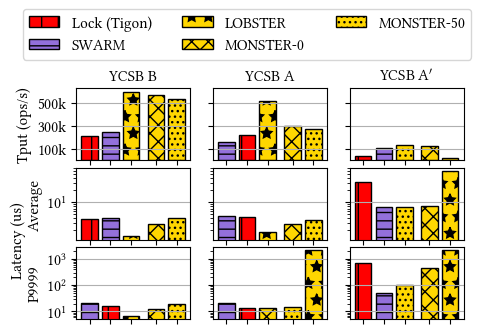

In [4]:
## global settings
colors = {
    LABEL_LOBSTER: "gold",
    LABEL_MONSTER0: "gold",
    LABEL_MONSTER50: "gold",
    LABEL_LOCK: "red",
    LABEL_SWARM: "mediumpurple" 
}

hatches = {
    LABEL_LOBSTER: "*",
    LABEL_MONSTER0: 'xx',
    LABEL_MONSTER50: "...",
    LABEL_LOCK: "|",
    LABEL_SWARM: "--" 
}

width   = 0.5
x = [1,2,3,4.2,5.2]
title_fontsize=11
fig, axs = plt.subplots(3, 3, figsize=(5, 3), gridspec_kw={"hspace": 0.1}, sharex="col", sharey="row")


## common barplot settings
def barplot(row, col, workload, metric, order):
    # x = [1,2,3,5,6]
    ax = axs[row][col]
    ax.grid(axis="y")
    heights = [workload[label][metric] for label in order]
    colors_ordered = [colors[label] for label in order]
    hatches_ordered = [hatches[label] for label in order]
    ax.bar(x, heights, ec='black', hatch=hatches_ordered, color=colors_ordered, label=order)

# tput
axs[0][0].set_yticks(
        [100_000, 300_000, 500_000],
        labels=["100k", "300k", "500k"],
    )

metric = "tput"

axs[0][0].set_title("YCSB B", fontsize=title_fontsize)
order = [LABEL_LOCK, LABEL_SWARM, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(0,0,ycsbb,metric,order)

axs[0][1].set_title("YCSB A", fontsize=title_fontsize)
order = [LABEL_SWARM, LABEL_LOCK, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(0,1,ycsba,metric,order)

axs[0][2].set_title("YCSB A$'$", fontsize=title_fontsize)
order = [LABEL_LOCK, LABEL_SWARM, LABEL_MONSTER50, LABEL_MONSTER0, LABEL_LOBSTER]
barplot(0,2,ycsba_single,metric,order)


# latency (row 1)
axs[1][0].set_yscale("log")

metric = "avglat"


order = [LABEL_LOCK, LABEL_SWARM, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(1,0,ycsbb,metric,order)

order = [LABEL_SWARM, LABEL_LOCK, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(1,1,ycsba,metric,order)

order = [LABEL_LOCK, LABEL_SWARM, LABEL_MONSTER50, LABEL_MONSTER0, LABEL_LOBSTER]
barplot(1,2,ycsba_single,metric,order)

# p9999 latency (row 2)
axs[2][0].set_yscale("log")
axs[2][0].set_xticks(x,labels=[])
axs[2][1].set_xticks(x,labels=[])
axs[2][2].set_xticks(x,labels=[])
metric = "p9999"

order = [LABEL_SWARM, LABEL_LOCK, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(2,0,ycsbb,metric,order)

order = [LABEL_SWARM, LABEL_LOCK, LABEL_MONSTER0, LABEL_MONSTER50, LABEL_LOBSTER]
barplot(2,1,ycsba,metric,order)


order = [LABEL_LOCK, LABEL_SWARM, LABEL_MONSTER50, LABEL_MONSTER0, LABEL_LOBSTER]
barplot(2,2,ycsba_single,metric,order)

# legend
axs[0][0].legend(loc="upper center", bbox_to_anchor=(1.5, 2.2), ncols=3,)

# Y label
axs[0][0].set_ylabel("Tput (ops/s)")
ax = axs[1][0]
ax.text(-0.58, -0, "Latency (us)",   transform=ax.transAxes, ha='left', va='center', rotation=90, clip_on=False)
axs[1][0].set_ylabel("Average", labelpad=2)
axs[2][0].set_ylabel("P9999", labelpad=2)


In [5]:
fig.savefig("barplot_comparison.pdf",bbox_inches = "tight", dpi=150)

# Throughput scale
Maximum number of throughput achievable by the system as the number of clients increases.

- 3 memory nodes
- 10 read retries
- workload: YCSB A
- 64B

In [6]:
# ── series styles ──────────────────────────────────────────────────────────────
linestyles = {
    LABEL_LOBSTER: "-*",
    LABEL_MONSTER0: "-x",
    LABEL_MONSTER50: "-..",
    LABEL_LOCK: "--3",
    LABEL_SWARM: "--v" 
}

linecolors = {
    LABEL_LOBSTER: "gold",
    LABEL_MONSTER0: "gold",
    LABEL_MONSTER50: "gold",
    LABEL_LOCK: "red",
    LABEL_SWARM: "mediumpurple" 
}

markerfill = "gold"
markerline = "black"

In [91]:
num_of_clients = np.array([4,     8,     12,     16,     20,     24,     28,     32,    36,     40,     44,     48,     52,     56,     60,     64,     68,     72, 80, 88, 96])
abe_tput_avg = np.array([546062, 526652, 500023, 474240, 449536, 432529, 409675, 393462,384002, 365792, 347056, 329120, 313401, 294271, 279083, 260001, 204117, 188186, 168308, 155518, 143587])
monster1300r_tput_avg = np.array( 
                        [263015, 260025, 256233, 250955, 241714, 236316, 230709, 225870, 224414, 219263, 209480, 203697, 197392, 190755, 184823, 172462, 86681, 78885, 64406, 50240, 45088])
abe_tput_total_Mops = num_of_clients * abe_tput_avg / 1_000_000
monster1300r_tput_total_Mops = num_of_clients * monster1300r_tput_avg / 1_000_000

### downsampled, comment out for full data
num_of_clients = np.array([4,     8,     12,     20,     28,     36,     44,     48,     56,     64,     72,     80,      88,    96])
abe_tput_avg = np.array([546062, 526652, 500023, 449536, 409675, 384002, 347056, 329120, 279083, 204117, 188186, 168308, 155518, 143587])
monster1300r_tput_avg = np.array(
                        [263015, 260025, 256233, 241714, 230709, 224414, 203697, 190755, 172462, 86681,  78885,  64406,  50240, 45088])
abe_tput_total_Mops = num_of_clients * abe_tput_avg / 1_000_000
monster1300r_tput_total_Mops = num_of_clients * monster1300r_tput_avg / 1_000_000


abe_avglat = [1.45, 1.53, 1.62, 1.83, 2.00, 2.17, 2.36, 2.59, 2.87, 3.36, 4.80, 5.54, 6.07, 6.5]
monster1300r_avglat = [3.39, 3.46, 3.51, 3.73, 3.905, 4.025, 4.32, 4.435, 4.77, 5.355, 12.315, 15.155, 19.575, 21.865 ]

lock_noclients = np.array([4,8,12,20,28,36,44,48,56,64,72,80,88,96])
lock_tput_avg = np.array([225226, 223733, 222660, 210817, 197153, 
                          155133, 95229, 80573, 58576, 45432, 28467, 
                          21637, 18712, 16691])
lock_tput_total_Mops = lock_noclients * lock_tput_avg / 1_000_000 
lock_avglat = [3.925, 3.98, 3.995, 4.23, 4.54, 5.915, 10.23, 12.22, 17.415, 23.005, 37.22, 50.29, 58.52, 66.885]

swarm_noclients = np.array([4,8,12,20,28,36,44,48,56,64])
swarm_tput_avg = np.array([171156, 156875, 138750, 92450, 61620, 46110, 37270, 34050, 28850, 24849])
swarm_avglat = np.array([4.16,4.52, 5.05, 7.5, 11.18, 14.79, 18.26, 19.96, 23.61, 27.27])
swarm_total_Mops = swarm_noclients * swarm_tput_avg / 1_000_000 
# swarm_total_Mops

swarmbatch_tput_avg = np.array([404745, 386500, 335000, 204880, 141888, 99664, 86548, 75720, 67240, 57614])
swarmbatch_avglat = np.array([8.946,  9.702, 10.605, 15.95 , 27.678, 31.269, 38.556, 41.916, 50.211, 58.758])
swarmbatch_total_Mops = swarm_noclients * swarmbatch_tput_avg / 1_000_000 
swarmbatch_total_Mops

array([1.61898 , 3.092   , 4.02    , 4.0976  , 3.972864, 3.587904,
       3.808112, 3.63456 , 3.76544 , 3.687296])

In [92]:
swarmbatch_avglat * 2.1

array([ 18.7866,  20.3742,  22.2705,  33.495 ,  58.1238,  65.6649,
        80.9676,  88.0236, 105.4431, 123.3918])

In [99]:
print("overall throughput")

print('\tlobster\tmonster50\tlock\tswarm\tswarm batched')

for i, c in enumerate(swarm_noclients):
    print(f'#{c}: \t{abe_tput_total_Mops[i]:.2f}\t{monster1300r_tput_total_Mops[i]:.2f}\t\t{lock_tput_total_Mops[i]:.2f}\t{swarm_total_Mops[i]:.2f}\t{swarmbatch_total_Mops[i]:.2f}' )


print("overall latency")

print('\tlobster\tmonster50\tlock\tswarm\tswarm batched')

for i, c in enumerate(swarm_noclients):
    print(f'#{c}: \t{abe_avglat[i]:.2f}\t{monster1300r_avglat[i]:.2f}\t\t{lock_avglat[i]:.2f}\t{swarm_avglat[i]:.2f}\t{swarmbatch_avglat[i]:.2f}' )


overall throughput
	lobster	monster50	lock	swarm	swarm batched
#4: 	2.18	1.05		0.90	0.68	1.62
#8: 	4.21	2.08		1.79	1.25	3.09
#12: 	6.00	3.07		2.67	1.67	4.02
#20: 	8.99	4.83		4.22	1.85	4.10
#28: 	11.47	6.46		5.52	1.73	3.97
#36: 	13.82	8.08		5.58	1.66	3.59
#44: 	15.27	8.96		4.19	1.64	3.81
#48: 	15.80	9.16		3.87	1.63	3.63
#56: 	15.63	9.66		3.28	1.62	3.77
#64: 	13.06	5.55		2.91	1.59	3.69
overall latency
	lobster	monster50	lock	swarm	swarm batched
#4: 	1.45	3.39		3.92	4.16	8.95
#8: 	1.53	3.46		3.98	4.52	9.70
#12: 	1.62	3.51		4.00	5.05	10.61
#20: 	1.83	3.73		4.23	7.50	15.95
#28: 	2.00	3.90		4.54	11.18	27.68
#36: 	2.17	4.03		5.92	14.79	31.27
#44: 	2.36	4.32		10.23	18.26	38.56
#48: 	2.59	4.43		12.22	19.96	41.92
#56: 	2.87	4.77		17.41	23.61	50.21
#64: 	3.36	5.36		23.00	27.27	58.76


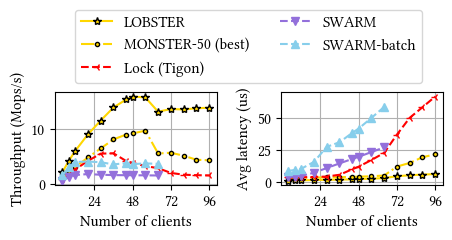

In [96]:
fig, axs = plt.subplots(1,2, figsize=(5, 1.2), gridspec_kw={"wspace": 0.4})

# plt.rcParams["font.size"] = 10
index_cut = 22
sbatch_color="skyblue"
ax = axs[0]
ax.grid()
ax.set_xticks([24,48,72,96])
# ax.set_title("Client scalability", fontsize=11)
ax.set_xlabel("Number of clients")
ax.set_ylabel("Throughput (Mops/s)")
ax.plot(num_of_clients[:index_cut], abe_tput_total_Mops[:index_cut], linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], markeredgecolor=markerline, markerfacecolor=markerfill, label=LABEL_LOBSTER)
ax.plot(num_of_clients[:index_cut], monster1300r_tput_total_Mops[:index_cut], linestyles[LABEL_MONSTER50], label="MONSTER-50 (best)", color=linecolors[LABEL_MONSTER50], markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(lock_noclients[:index_cut], lock_tput_total_Mops[:index_cut], linestyles[LABEL_LOCK], label=LABEL_LOCK, color=linecolors[LABEL_LOCK])
ax.plot(swarm_noclients[:index_cut], swarm_total_Mops[:index_cut], linestyles[LABEL_SWARM], label=LABEL_SWARM,  color=linecolors[LABEL_SWARM])
ax.plot(swarm_noclients[:index_cut], swarmbatch_total_Mops[:index_cut], '--^', label="SWARM-batch",  color=sbatch_color)
# ax.set_yscale("log")
# ax.set_ylim((0,2))

ax = axs[1]
ax.grid()
ax.set_xticks([24,48,72,96])
# ax.set_title("Client scalability", fontsize=11)
ax.set_xlabel("Number of clients")
ax.set_ylabel("Avg latency (us)")
ax.plot(num_of_clients[:index_cut], abe_avglat[:index_cut], linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], markeredgecolor=markerline, markerfacecolor=markerfill, label=LABEL_LOBSTER)
ax.plot(num_of_clients[:index_cut], monster1300r_avglat[:index_cut], linestyles[LABEL_MONSTER50], label="MONSTER-50 (best)", color=linecolors[LABEL_MONSTER50], markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(lock_noclients[:index_cut], lock_avglat[:index_cut], linestyles[LABEL_LOCK], label=LABEL_LOCK, color=linecolors[LABEL_LOCK])
ax.plot(swarm_noclients[:index_cut], swarm_avglat[:index_cut], linestyles[LABEL_SWARM], label=LABEL_SWARM,  color=linecolors[LABEL_SWARM])
ax.plot(swarm_noclients[:index_cut], swarmbatch_avglat[:index_cut], '--^', label="SWARM-batch",  color=sbatch_color)

axs[0].legend(loc="center", bbox_to_anchor=(1.2,1.5), ncols=2)



In [97]:
fig.savefig("client_scale.pdf",bbox_inches = "tight", dpi=150)

## Memory node scale

Scaling the number of nodes for YCSB A workload. The number of nodes impacts the write operations in monster and abe since reads have the first-last-only optimization. 

- read retries: 10
- num of processes: 9

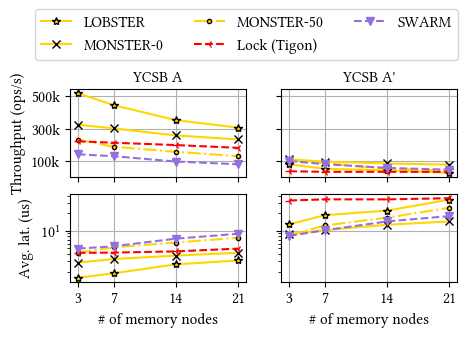

In [100]:
fig, axs = plt.subplots(2,2,figsize=(5, 2.5), sharey="row", sharex="col")

title_fontsize=11
mnodes = [3,7,14,21]

ax = axs[0][0]
ax.grid()
abe_tput= [517672, 444434, 352620, 306652]
abe_lat = [1.57, 1.87, 2.66, 3.1]
monsterasync_tput = [325026, 301641, 258823, 234177]
monsterasync_lat = [2.86, 3.28, 3.76, 4.2] 
monstersync_tput = [233451, 189537, 158530, 131540]
monstersync_lat = [4.24, 5.2, 6.3, 7.6]
lock_tput = [222723, 214223, 199820, 182842]
lock_lat = [4.2, 4.23, 4.44, 4.95]
swarm_tput = [143250, 131750, 98750, 82125]
swarm_lat = [4.95, 5.43, 7.33, 8.89]



# ./14nodes: 7326.5 ns
# ./21nodes: 8882.62 ns
# ./4nodes: 4954.44 ns
# ./7nodes: 5434 ns
########## YCSB A low contention
ax.set_title("YCSB A", fontsize=title_fontsize)
ax.plot(mnodes, abe_tput, linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(mnodes, monsterasync_tput, linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label=LABEL_MONSTER0, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, monstersync_tput, linestyles[LABEL_MONSTER50], color=linecolors[LABEL_MONSTER50], label=LABEL_MONSTER50, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, lock_tput, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.plot(mnodes, swarm_tput, linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)
# ax.set_xticks(mnodes)
ax.set_ylabel("Throughput (ops/s)")
ax.set_yticks([100_000, 300_000, 500_000], labels=["100k", "300k", "500k"])

ax = axs[1][0]
ax.grid()
ax.plot(mnodes, abe_lat, linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(mnodes, monsterasync_lat, linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label=LABEL_MONSTER0, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, monstersync_lat, linestyles[LABEL_MONSTER50], color=linecolors[LABEL_MONSTER50], label=LABEL_MONSTER50, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, lock_lat, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.plot(mnodes, swarm_lat, linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)
ax.set_xticks(mnodes)
ax.set_ylabel("Avg. lat. (us)")
ax.set_xlabel("# of memory nodes")




ax = axs[0][1]
ax.grid()
abe_tput= [82000, 54285, 45098, 30139]
abe_lat = [12.9, 18.5, 22.2, 34.1]
monsterasync_tput = [112000, 98375, 87000, 80000 ]
monsterasync_lat = [8.75, 10.29, 12.68, 14.44]
monstersync_tput = [ 113875, 87875, 54625, 43625 ]
monstersync_lat = [8.47, 12.32, 16.83, 24.8]
lock_tput = [39251, 35871, 35871, 35661]
lock_lat = [33, 34.53, 34.53, 36.15]
swarm_tput = [101750, 82750, 59625, 48750]
swarm_lat = [8.2, 10.22, 14.47, 17.86]

ax.set_title("YCSB A'",fontsize=title_fontsize)
ax.plot(mnodes, abe_tput, linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, monsterasync_tput, linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label=LABEL_MONSTER0, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, monstersync_tput,  linestyles[LABEL_MONSTER50], color=linecolors[LABEL_MONSTER50], label=LABEL_MONSTER50, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, lock_tput, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.plot(mnodes, swarm_tput, linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)

ax = axs[1][1]
ax.grid()
ax.plot(mnodes, abe_lat, linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(mnodes, monsterasync_lat, linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label=LABEL_MONSTER0, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, monstersync_lat, linestyles[LABEL_MONSTER50], color=linecolors[LABEL_MONSTER50], label=LABEL_MONSTER50, markeredgecolor=markerline, markerfacecolor=markerfill,)
ax.plot(mnodes, lock_lat, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.plot(mnodes, swarm_lat, linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)
ax.set_xticks(mnodes)
ax.set_xlabel("# of memory nodes")
ax.set_yscale("log")

axs[0][1].legend(loc="upper center", bbox_to_anchor=(-0.2, 2),ncols=3)

In [101]:
fig.savefig("memnode_scale.pdf",bbox_inches = "tight", dpi=150)

# Object size

- 3 memory nodes
- 10 read retries
- Workload A
- 9 processes

In [102]:
obj_size = np.array([16, 128, 1024, 8192])

abe_tput_ops = np.array([556277, 464237, 203590, 53250])
abe_rlat = np.array([1.63, 1.94, 6.00, 17.50])
abe_wlat = np.array([1.22, 1.48, 2.40, 14.41])
abe_avglat = (abe_rlat + abe_wlat)/2
abe_tput_ops_cumulative = abe_tput_ops * 9 / 1_000_000
abe_tput_GiB = obj_size * abe_tput_ops_cumulative /  1024

monster10r_tput_ops = np.array([312286, 285378, 172316, 51422])
monster10r_rlat = np.array([1.37, 1.55, 4.21, 15.48])
monster10r_wlat = np.array([4.31, 4.58, 5.47, 17.88])
monster10r_avglat = (monster10r_rlat+monster10r_wlat)/2
monster10r_tput_ops_cumulative = monster10r_tput_ops * 9 / 1_000_000
monster10r_tput_GiB = obj_size * monster10r_tput_ops_cumulative /  1024

monster1300r_tput_ops = np.array([266992, 244075, 160275, 50263])
monster1300r_rlat = np.array([1.36, 1.55, 3.78, 14.97])
monster1300r_wlat = np.array([5.46, 5.83, 6.77, 19.38])
monster1300r_avglat = (monster1300r_rlat + monster1300r_wlat) /2 
monster1300r_tput_ops_cumulative = monster1300r_tput_ops * 9 / 1_000_000
monster1300r_tput_GiB = obj_size * monster1300r_tput_ops_cumulative /  1024

lock_tput_ops = np.array([225745, 214186, 161705, 62572])
lock_rlat = np.array([4.67, 4.78, 5.55, 11.08])
lock_wlat = np.array([3.24, 3.44, 4.67, 15.23])
lock_avglat = (lock_rlat + lock_wlat)/2
lock_tput_ops_cumulative = lock_tput_ops * 9 / 1_000_000
lock_tput_GiB = obj_size * lock_tput_ops_cumulative /  1024


swarm_objsize = np.array([12,128,1024,4096])
swarm_tput_ops = np.array([177375, 159375, 125875, 85250])
swarm_avglat = np.array([ 3.98, 4.49, 5.88, 9.030])
swarm_tput_ops_cumulative = swarm_tput_ops * 9 / 1_000_000
swarm_tput_GiB = swarm_objsize * swarm_tput_ops_cumulative /  1024 

########## YCSB B

b_abe_tput_ops = np.array([616651, 536264, 257953, 63461])
b_abe_rlat = np.array([1.41, 1.65, 3.64, 14.96])
b_abe_wlat = np.array([1.20, 1.42, 2.31, 14.48])
b_abe_avglat = (b_abe_rlat+b_abe_wlat)/2
b_abe_tput_ops_cumulative = b_abe_tput_ops * 9 / 1_000_000
b_abe_tput_GiB = obj_size * b_abe_tput_ops_cumulative /  1024

b_monster10r_tput_ops = np.array([579871, 520537, 249711, 65091])
b_monster10r_rlat = np.array([1.36, 1.54, 3.61, 14.34])
b_monster10r_wlat = np.array([4.21, 4.45, 5.39, 17.98])
b_monster10r_avglat = (b_monster10r_wlat + b_monster10r_rlat)/2
b_monster10r_tput_ops_cumulative = b_monster10r_tput_ops * 9 / 1_000_000
b_monster10r_tput_GiB = obj_size * b_monster10r_tput_ops_cumulative /  1024
98442
# b_monster1300r_tput_ops = np.array([266992, 244075, 160275, 50263])
# b_monster1300r_rlat = np.array([1.36, 1.55, 3.78, 14.97])
# b_monster1300r_wlat = np.array([5.46, 5.83, 6.77, 19.38])
# b_monster1300r_tput_ops_cumulative = monster1300r_tput_ops * 9
# b_monster1300r_tput_GiB = obj_size * monster1300r_tput_ops_cumulative /  1024

b_lock_tput_ops = np.array([212029, 207711, 185286, 98442])
b_lock_rlat = np.array([4.54, 4.62, 5.11, 9.24])
b_lock_wlat = np.array([3.26, 3.44, 4.57, 13.06])
b_lock_avglat = (b_lock_rlat + b_lock_wlat) / 2
b_lock_tput_ops_cumulative = b_lock_tput_ops * 9 / 1_000_000
b_lock_tput_GiB = obj_size * b_lock_tput_ops_cumulative /  1024


b_swarm_objsize = np.array([12,128,1024,4096])
b_swarm_tput_ops = np.array([274250, 251000, 202125, 131930])
b_swarm_avglat = np.array([ 3.74, 4.1, 5.22, 8.93]) 
b_swarm_tput_ops_cumulative = b_swarm_tput_ops * 9 / 1_000_000
b_swarm_tput_GiB = swarm_objsize * b_swarm_tput_ops_cumulative /  1024 

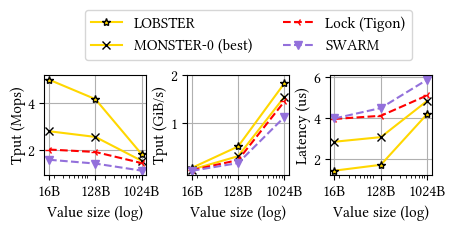

In [105]:
fig, axs = plt.subplots(1,3, figsize=(5,1.3), sharex="all", gridspec_kw={"wspace":0.4, "hspace":0.1})

x = [16, 128, 1024]
titlesize = 11

ax = axs[0]
# ax.set_title("YCSB A",fontsize=titlesize)
ax.grid()
ax.set_xscale("log")
ax.set_ylabel("Tput (Mops)", labelpad=1.5)
ax.set_xlabel("Value size (log)")
ax.set_yticks([2,4])

ax.plot(x, abe_tput_ops_cumulative[:len(x)],  linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(x, monster10r_tput_ops_cumulative[:len(x)],  linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)", markeredgecolor=markerline, markerfacecolor=markerfill)
# ax.plot(x, monster1300r_tput_ops_cumulative, STYLE_MONSTER_R)
ax.plot(x, lock_tput_ops_cumulative[:len(x)], linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.plot(x, swarm_tput_ops_cumulative[:len(x)], linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)

ax = axs[1]
ax.grid()
ax.plot(x, abe_tput_GiB[:len(x)], linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(x, monster10r_tput_GiB[:len(x)],  linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)", markeredgecolor=markerline, markerfacecolor=markerfill)
# ax.plot(x, monster1300r_tput_GiB, STYLE_MONSTER_R)
ax.plot(x, lock_tput_GiB[:len(x)], linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.plot(x, swarm_tput_GiB[:len(x)], linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)
ax.set_ylabel("Tput (GiB/s)", labelpad=1.5)
ax.set_yticks([1,2])
ax.set_xlabel("Value size (log)")


ax = axs[2]
ax.grid()
ax.set_xlabel("Value size (log)")
ax.set_ylabel("Latency (us)", labelpad=1.5)
ax.set_yticks([2,4,6])
ax.plot(x, abe_avglat[:len(x)], linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(x, monster10r_avglat[:len(x)],  linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)", markeredgecolor=markerline, markerfacecolor=markerfill)
ax.plot(x, lock_avglat[:len(x)], linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.plot(x, swarm_avglat[:len(x)], linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)

ax.set_xticks(x, labels=["16B","128B","1024B"])



# ax = axs[0][1]
# ax.set_title("YCSB B", fontsize=titlesize)
# ax.grid()

# ax.plot(x, b_abe_tput_ops_cumulative[:len(x)],  linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill)
# ax.plot(x, b_monster10r_tput_ops_cumulative[:len(x)], linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)", markeredgecolor=markerline, markerfacecolor=markerfill)
# ax.plot(x, b_lock_tput_ops_cumulative[:len(x)], linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
# ax.plot(x, b_swarm_tput_ops_cumulative[:len(x)], linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)

# ax = axs[1][1]
# ax.grid()
# ax.plot(x, b_abe_tput_GiB[:len(x)], linestyles[LABEL_LOBSTER], markeredgecolor=markerline, markerfacecolor=markerfill)
# ax.plot(x, b_monster10r_tput_GiB[:len(x)], linestyles[LABEL_MONSTER0], markeredgecolor=markerline, markerfacecolor=markerfill,)
# ax.plot(x, b_lock_tput_GiB[:len(x)],linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
# ax.plot(x, b_swarm_tput_GiB[:len(x)], linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)

# ax = axs[2][1]
# ax.set_xlabel("Value size")
# ax.grid()
# ax.plot(x, b_abe_avglat[:len(x)], linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER, markeredgecolor=markerline, markerfacecolor=markerfill,)
# ax.plot(x, b_monster10r_avglat[:len(x)], linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)", markeredgecolor=markerline, markerfacecolor=markerfill,)
# ax.plot(x, b_lock_avglat[:len(x)], linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
# ax.plot(x, b_swarm_avglat[:len(x)], linestyles[LABEL_SWARM], color=linecolors[LABEL_SWARM], label=LABEL_SWARM)



axs[2].legend(loc="center", bbox_to_anchor=(-0.8,1.4), ncols=2)



In [106]:
fig.savefig("objsize_scale.pdf",bbox_inches = "tight", dpi=150)